# HW4 Task 1: GHZ State Implementation

## Introduction

In this notebook, we implement and execute a GHZ (Greenberger-Horne-Zeilinger) state on both a quantum simulator and a real quantum computer.

A GHZ state is a maximally entangled quantum state involving multiple qubits. For n qubits, the GHZ state is:

$$|GHZ\rangle = \frac{1}{\sqrt{2}}(|00...0\rangle + |11...1\rangle)$$

This state demonstrates quantum entanglement across all qubits - measuring any single qubit immediately affects all others. -->

In [34]:
# Import necessary libraries
from qiskit import QuantumCircuit, transpile
from qiskit_aer import AerSimulator
from qiskit_ibm_runtime import QiskitRuntimeService, SamplerV2 as Sampler
from qiskit.visualization import plot_histogram, plot_distribution
import matplotlib.pyplot as plt
import numpy as np

print("Libraries imported successfully!")

Libraries imported successfully!


## IBM Quantum Setup

To run on real quantum hardware, we need to authenticate with IBM Quantum.

**Note**: You only need to save your token once. After that, it's stored locally.

In [35]:
# Save your IBM Quantum token (only needed once)
# Uncomment and run this cell if you haven't saved your token yet
# QiskitRuntimeService.save_account(channel="ibm_quantum", token="YOUR_API_TOKEN_HERE", overwrite=True)

# Load the service
try:
    service = QiskitRuntimeService()
    print("✓ IBM Quantum service loaded successfully!")
    
    # Show available backends
    backends = service.backends()
    backend_names = [b.name for b in backends]
    print(f"✓ Available backends: {backend_names}")
    
except Exception as e:
    print(f"Could not load IBM Quantum service: {e}")
    print("Will run on simulator only.")
    service = None

qiskit_runtime_service.__init__:WARNING:2026-01-01 20:53:54,721: Instance was not set at service instantiation. Free and trial plan instances will be prioritized. Based on the following filters: (tags: None, region: us-east, eu-de), and available plans: (open), the available account instances are: open-instance. If you need a specific instance set it explicitly either by using a saved account with a saved default instance or passing it in directly to QiskitRuntimeService().
qiskit_runtime_service.backends:WARNING:2026-01-01 20:53:54,721: Loading instance: open-instance, plan: open


✓ IBM Quantum service loaded successfully!
✓ Available backends: ['ibm_fez', 'ibm_marrakesh', 'ibm_torino']


## Creating the GHZ Circuit

The GHZ circuit is created as follows:
1. Apply Hadamard gate to the first qubit (creates superposition)
2. Apply CNOT gates from first qubit to all other qubits (creates entanglement)
3. Measure all qubits

We'll start with 15 qubits as suggested in the assignment.

In [36]:
def create_ghz_circuit(num_qubits):
    """
    Create a GHZ state circuit for num_qubits qubits.
    Args:
        num_qubits: Number of qubits in the circuit
    Returns:
        QuantumCircuit: The GHZ circuit
    """
    qc = QuantumCircuit(num_qubits, num_qubits)
    
    # Apply Hadamard gate to first qubit
    qc.h(0)
    
    # Apply CNOT gates from first qubit to all others
    for i in range(1, num_qubits):
        qc.cx(0, i)
    
    # Measure all qubits
    qc.measure(range(num_qubits), range(num_qubits))
    
    return qc

# Create the circuit with 15 qubits
num_qubits = 15
ghz_circuit = create_ghz_circuit(num_qubits)

print(f"Created GHZ circuit with {num_qubits} qubits")
print(f"Circuit depth: {ghz_circuit.depth()}")
print(f"Number of gates: {len(ghz_circuit.data)}")

Created GHZ circuit with 15 qubits
Circuit depth: 16
Number of gates: 30


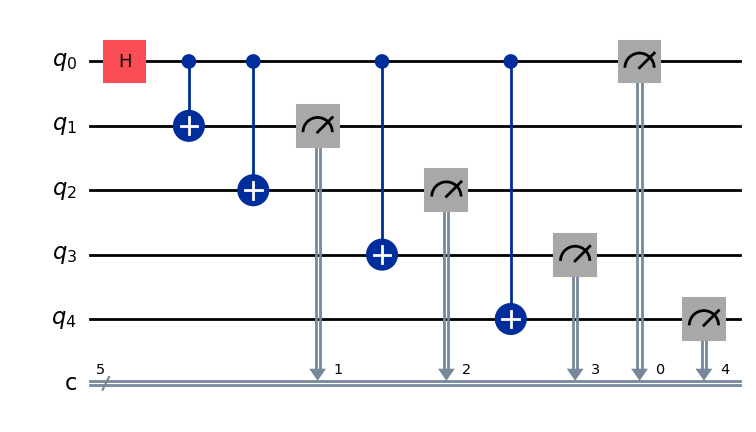

In [37]:
# Visualize the circuit (for smaller version)
ghz_circuit_small = create_ghz_circuit(5)  # Smaller for better visualization
ghz_circuit_small.draw('mpl')

## Running on Simulator

First, let's run the circuit on a local simulator. We expect to see only two outcomes: all 0s or all 1s.

In [38]:
# Run on Aer simulator
simulator = AerSimulator()
shots = 1024

# Transpile for simulator
transpiled_circuit = transpile(ghz_circuit, simulator)

# Run the circuit
job = simulator.run(transpiled_circuit, shots=shots)
result = job.result()
counts_sim = result.get_counts()

print(f"Simulator results for {num_qubits} qubits:")
print(f"Total outcomes observed: {len(counts_sim)}")
print(f"\nTop 5 outcomes:")
for outcome, count in sorted(counts_sim.items(), key=lambda x: x[1], reverse=True)[:5]:
    print(f"  {outcome}: {count} ({count/shots*100:.1f}%)")

Simulator results for 15 qubits:
Total outcomes observed: 2

Top 5 outcomes:
  000000000000000: 519 (50.7%)
  111111111111111: 505 (49.3%)


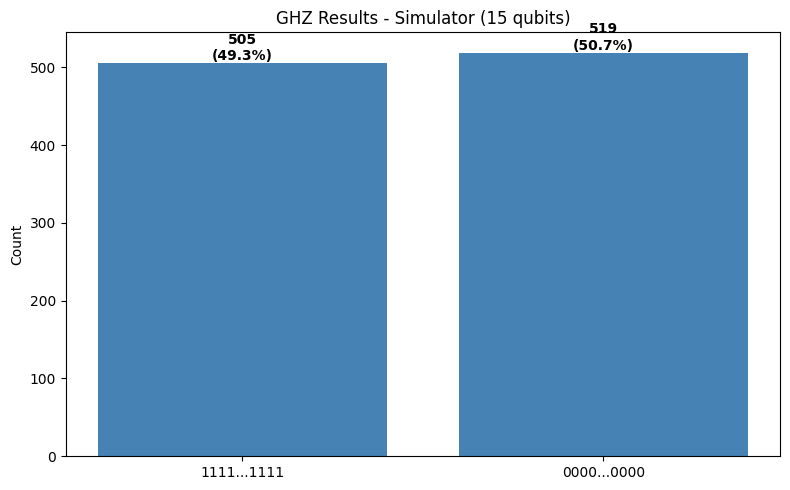

In [39]:
# Plot only observed outcomes (better for many qubits)
plt.figure(figsize=(8, 5))
outcomes = list(counts_sim.keys())
counts = list(counts_sim.values())
plt.bar(range(len(outcomes)), counts, color='steelblue')
plt.xticks(range(len(outcomes)), [f'{o[:4]}...{o[-4:]}' for o in outcomes])
plt.ylabel('Count')
plt.title(f'GHZ Results - Simulator ({num_qubits} qubits)')
for i, c in enumerate(counts):
    plt.text(i, c, f'{c}\n({c/shots*100:.1f}%)', ha='center', va='bottom', fontweight='bold')
plt.tight_layout()
plt.show()

## Running on Real Quantum Hardware

Now let's run the same circuit on a real quantum computer. We'll use IBM's least busy backend.

**Note**: Real quantum hardware is noisy, so we expect to see more varied outcomes due to:
- Gate errors
- Decoherence
- Measurement errors
- Cross-talk between qubits

In [ ]:
if service is not None:
    # Get the least busy backend with enough qubits
    backend = service.least_busy(operational=True, simulator=False, min_num_qubits=num_qubits)
    print(f"Selected backend: {backend.name}")
    print(f"Backend has {backend.num_qubits} qubits")
    
    # Transpile for the specific backend
    transpiled_qpu = transpile(ghz_circuit, backend, optimization_level=3)
    print(f"Transpiled circuit depth: {transpiled_qpu.depth()}")
    
    # Run on QPU using Sampler
    sampler = Sampler(backend)
    job = sampler.run([transpiled_qpu], shots=shots)
    print(f"Job ID: {job.job_id()}")
    print("Job submitted, waiting for results...")
    print("(This may take several minutes depending on queue)")
    
    result_qpu = job.result()
    
    # Get counts from the result
    try:
        counts_qpu = result_qpu[0].data.c.get_counts()
    except:
        # Fallback: get the first measurement register
        counts_qpu = result_qpu[0].data[list(result_qpu[0].data.keys())[0]].get_counts()
    
    print(f"\nQPU results for {num_qubits} qubits:")
    print(f"Total outcomes observed: {len(counts_qpu)}")
    print(f"\nTop 5 outcomes:")
    for outcome, count in sorted(counts_qpu.items(), key=lambda x: x[1], reverse=True)[:5]:
        print(f"  {outcome}: {count} ({count/shots*100:.1f}%)")
else:
    print("Skipping QPU run - service not available")
    counts_qpu = None

qiskit_runtime_service.backends:WARNING:2026-01-01 20:56:38,586: Loading instance: open-instance, plan: open
qiskit_runtime_service.backends:WARNING:2026-01-01 20:56:39,700: Using instance: open-instance, plan: open


Selected backend: ibm_torino
Backend has 133 qubits
Transpiled circuit depth: 84
Job ID: d5bc6qbht8fs73a6glt0
Job submitted, waiting for results...
(This may take several minutes depending on queue)

QPU results for 15 qubits:
Total outcomes observed: 200

Top 5 outcomes:
  000000000000000: 305 (29.8%)
  111111111111111: 245 (23.9%)
  111111111101111: 28 (2.7%)
  000000000000100: 17 (1.7%)
  000000001000000: 15 (1.5%)


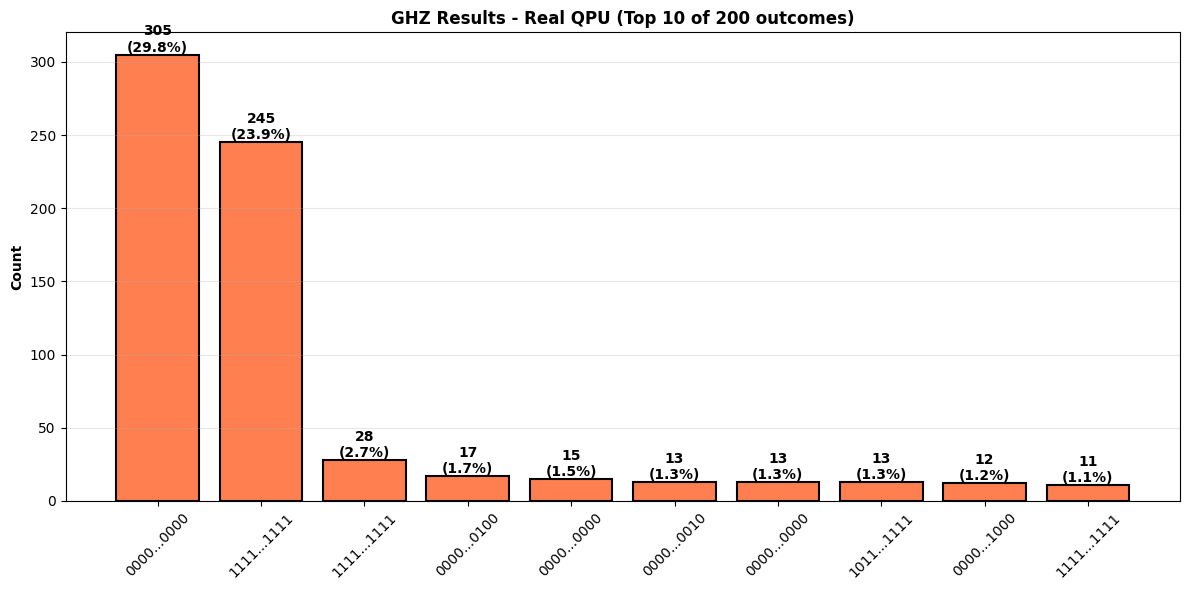

In [ ]:
if counts_qpu is not None:
    # Show only top 10 outcomes
    top_counts = dict(sorted(counts_qpu.items(), key=lambda x: x[1], reverse=True)[:10])
    
    plt.figure(figsize=(12, 6))
    outcomes = list(top_counts.keys())
    counts = list(top_counts.values())
    
    # Bar chart
    bars = plt.bar(range(len(outcomes)), counts, color='coral', edgecolor='black', linewidth=1.5)
    
    # Add percentages on bars
    for i, (bar, c) in enumerate(zip(bars, counts)):
        plt.text(bar.get_x() + bar.get_width()/2., c, 
                f'{c}\n({c/shots*100:.1f}%)', 
                ha='center', va='bottom', fontweight='bold')
    
    # Labels (shortened)
    plt.xticks(range(len(outcomes)), [f'{o[:4]}...{o[-4:]}' for o in outcomes], rotation=45)
    plt.ylabel('Count', fontweight='bold')
    plt.title(f'GHZ Results - Real QPU (Top 10 of {len(counts_qpu)} outcomes)', fontweight='bold')
    plt.grid(axis='y', alpha=0.3)
    plt.tight_layout()
    plt.show()

## Comparing Simulator vs Real Hardware

Let's compare the results side by side.

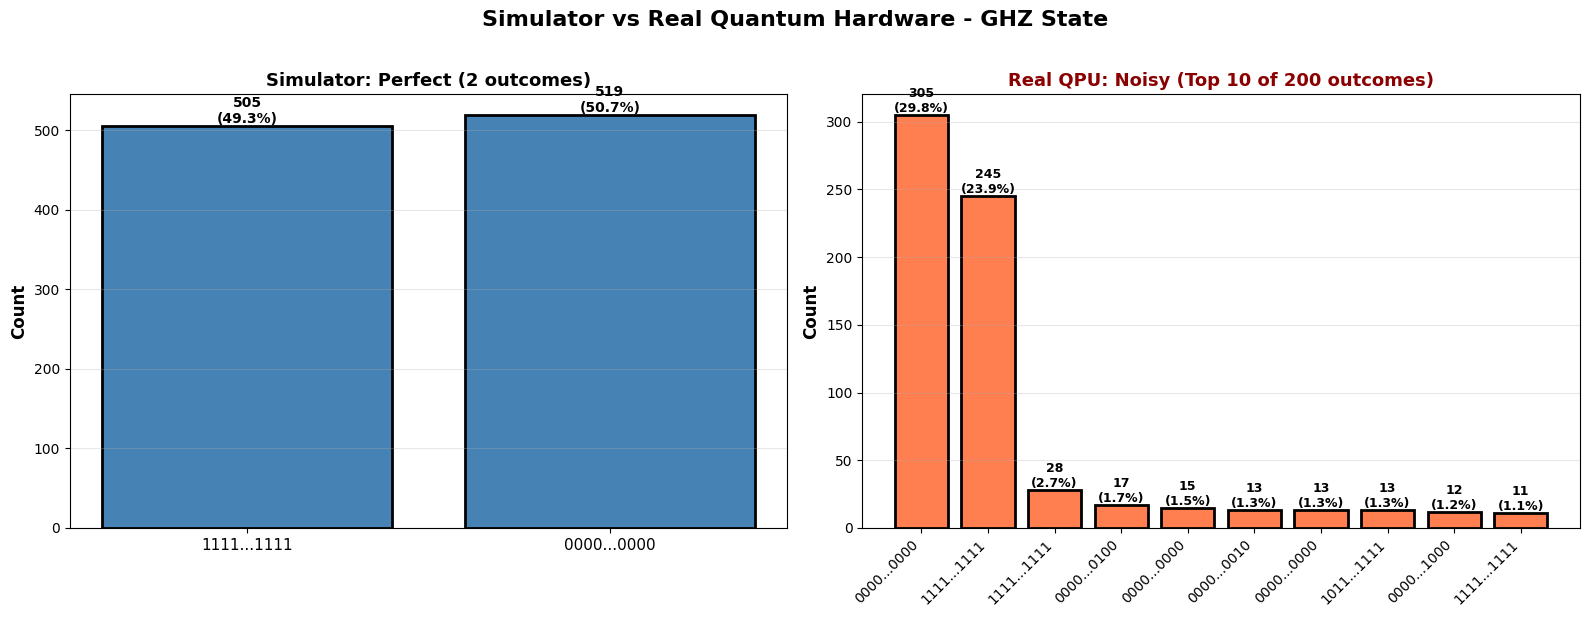

In [45]:
if counts_qpu is not None:
    fig, axes = plt.subplots(1, 2, figsize=(16, 6))
    
    # LEFT: Simulator (all outcomes)
    sim_outcomes = list(counts_sim.keys())
    sim_counts = list(counts_sim.values())
    axes[0].bar(range(len(sim_outcomes)), sim_counts, color='steelblue', edgecolor='black', linewidth=2)
    axes[0].set_xticks(range(len(sim_outcomes)))
    axes[0].set_xticklabels([f'{o[:4]}...{o[-4:]}' for o in sim_outcomes], fontsize=11)
    axes[0].set_ylabel('Count', fontsize=12, fontweight='bold')
    axes[0].set_title(f'Simulator: Perfect ({len(counts_sim)} outcomes)', fontsize=13, fontweight='bold')
    axes[0].grid(axis='y', alpha=0.3)
    # Add percentages on bars
    for i, c in enumerate(sim_counts):
        axes[0].text(i, c, f'{c}\n({c/shots*100:.1f}%)', ha='center', va='bottom', fontweight='bold')
    
    # RIGHT: QPU (top 10 only)
    top_qpu = dict(sorted(counts_qpu.items(), key=lambda x: x[1], reverse=True)[:10])
    qpu_outcomes = list(top_qpu.keys())
    qpu_counts = list(top_qpu.values())
    axes[1].bar(range(len(qpu_outcomes)), qpu_counts, color='coral', edgecolor='black', linewidth=2)
    axes[1].set_xticks(range(len(qpu_outcomes)))
    axes[1].set_xticklabels([f'{o[:4]}...{o[-4:]}' for o in qpu_outcomes], rotation=45, ha='right', fontsize=10)
    axes[1].set_ylabel('Count', fontsize=12, fontweight='bold')
    axes[1].set_title(f'Real QPU: Noisy (Top 10 of {len(counts_qpu)} outcomes)', fontsize=13, fontweight='bold', color='darkred')
    axes[1].grid(axis='y', alpha=0.3)
    # Add percentages on bars
    for i, c in enumerate(qpu_counts):
        axes[1].text(i, c, f'{c}\n({c/shots*100:.1f}%)', ha='center', va='bottom', fontweight='bold', fontsize=9)
    
    plt.suptitle('Simulator vs Real Quantum Hardware - GHZ State', fontsize=16, fontweight='bold', y=1.02)
    plt.tight_layout()
    plt.show()

## Analysis and Conclusions

### Expected Behavior (Simulator)
In an ideal quantum computer (simulator), the GHZ state should only produce two outcomes:
- All qubits measured as 0: `000...000`
- All qubits measured as 1: `111...111`

These should appear with approximately equal probability (~50% each).

### Real Hardware Behavior
On real quantum hardware, we observe:

1. **Noise and Errors**: Instead of just two outcomes, we see many different bitstrings. This is due to:
   - **Gate errors**: Imperfect implementation of quantum gates
   - **Decoherence**: Qubits losing their quantum properties over time
   - **Measurement errors**: Incorrect measurement outcomes
   - **Cross-talk**: Unwanted interactions between qubits

2. **Reduced Fidelity**: The correct states (`000...000` and `111...111`) appear less frequently than in simulation.

3. **Error Patterns**: Errors tend to accumulate, especially in longer circuits and with more qubits. The GHZ circuit, while simple, is sensitive to errors because all qubits are entangled.

### Key Takeaways
- Quantum simulators give us ideal, noise-free results
- Real quantum computers are currently noisy intermediate-scale quantum (NISQ) devices
- Error mitigation and quantum error correction are active research areas
- The quality of results depends on backend quality, circuit depth, and number of qubits used